# Portfolio problem

In [92]:
import math
from pathlib import Path
# import cvxpy as cp
import numpy as np
import pandas as pd
# import scipy as sp
import matplotlib.pyplot as plt
import pickle

from mis_dro.dataset import get_portfolio_returns_df, get_window_of_train_and_test_dataframes
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *
from mis_dro.portfolio import portfolio_objective_cvxpy, calculate_transaction_cost
from mis_dro.preprocessing import normalise_by_dimension
from mis_dro.metrics import calculate_sharpe_ratio, calculate_sortino_ratio

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=False)

import datetime as dt

In [93]:
# TODO: refactor things a bit

compare_with_original = False
james_windows = True
include_transaction_costs = True

# TODO: set to False outside of testing
use_markowitz_development_script_for_normal_runs = False
use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function = False
use_markowitz_development_script_for_shv_runs_with_transaction_costs_in_cost_function = False

if compare_with_original:
    james_windows = False
    include_transaction_costs = False

In [94]:
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025"
kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

if compare_with_original:
    kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

kl_experiment_dir = Path(kl_experiment_dir_string)
assert kl_experiment_dir.exists()

mmc2_dir = Path("/", "dcs", "pg24", "u5674159", "datasets", "misdro", "mmc2")
assert mmc2_dir.exists()

if james_windows:

    # TODO: move other data files into james-data
    experiment_dir_data_dir_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20160427_inclusive_every_12_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20250730_inclusive_every_4_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/windows_19971001_to_20250702_inclusive_every_4_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl"
    }

    experiment_dir_num_test_weeks_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": 12,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": 13,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": 13
    }

    experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl"
    }

    # TODO: move other data files into james-data
    # experiment_dir_djia_level_file_map = {
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy"
    # }

    experiment_dir_markowitz_file_map_normal_runs_without_transaction_costs_in_results = {
        "ipynb": {
            "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/ipynb_results_for_multiple_lambdas.pkl"
        },
        "slurm": {
            # NOTE: I don't even think the below key and value are comparable as I think they were generated using different Slurm setups
            # "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl",
            "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl"
        }
    }

    def get_markowitz_validation_results_with_transaction_costs_in_results(corresponding_kl_experiment_dir_string, from_ipynb, transaction_costs_in_cost_function, validation_type):
        assert corresponding_kl_experiment_dir_string == "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
        assert validation_type in ("single_holdout_validation", "rolling_validation_10_folds")
        base_path = "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/"
        base_path += ("ipynb_" if from_ipynb else "")
        base_path += f"results_for_best_lambdas_from_{validation_type}_with_"
        results = {}
        for ratio_type in ("sharpe", "sortino"):
            path = base_path + ratio_type
            if transaction_costs_in_cost_function:
                path += "_with_transaction_costs_in_cost_function"
            path += ".pkl"
            results[ratio_type] = path
        return results

    # # NOTE that these already have test ratios as well as out_of_sample_cost having transaction costs applied to them already
    # experiment_dir_shv_experiment_dir_map = {
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": {
    #         "sharpe": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sharpe",
    #         "sortino": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sortino"
    #     }
    # }
    experiment_dir_validation_experiment_dir_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": {
            "shv": {
                "sharpe": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sharpe",
                "sortino": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sortino"
            },
            "rolling_validation": {
                "sharpe": "/dcs/pg24/u5674159/mis-dro-code/rolling-tv-normal-cost-function-sharpe",
                "sortino": "/dcs/pg24/u5674159/mis-dro-code/rolling-tv-normal-cost-function-sortino"
            }
        }
    }

    def get_kl_dro_validation_results_with_transaction_costs_in_results(corresponding_kl_experiment_dir_string, validation_type, transaction_costs_in_cost_function):
        assert corresponding_kl_experiment_dir_string == "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
        assert validation_type in ["shv", "rolling_validation"]
        if transaction_costs_in_cost_function:
            assert validation_type == "rolling_validation"
        base_path = "/dcs/pg24/u5674159/mis-dro-code/"
        if validation_type == "shv":
            base_path += "shv-"
        elif validation_type == "rolling_validation":
            base_path += "rolling-tv-"
        else:
            raise NotImplementedError()
        if transaction_costs_in_cost_function:
            base_path += "optimise-transaction-costs-"
        else:
            base_path += "normal-cost-function-"
        results = {}
        for ratio_type in ["sharpe", "sortino"]:
            results[ratio_type] = base_path + ratio_type
        return results

    james_djia_data_path_string = experiment_dir_data_dir_map[kl_experiment_dir_string]
    james_djia_data_path = Path(james_djia_data_path_string)

    num_test_weeks = experiment_dir_num_test_weeks_map[kl_experiment_dir_string]

    james_benchmark_from_price_weighted_portfolio_weightings_map_file = experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map[kl_experiment_dir_string]
    # james_djia_level_file = experiment_dir_djia_level_file_map[kl_experiment_dir_string]

    james_markowitz_results_file_normal_runs_without_transaction_costs = experiment_dir_markowitz_file_map_normal_runs_without_transaction_costs_in_results["slurm" if not use_markowitz_development_script_for_normal_runs else "ipynb"][kl_experiment_dir_string]

    dict_for_markowitz_results_files_shv_with_tcosts_in_results = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, False, "single_holdout_validation")
    dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, False, "rolling_validation_10_folds")
    dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results_and_cost_function = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, True, "rolling_validation_10_folds")

    risk_free_rates_file = "/dcs/pg24/u5674159/mis-dro-code/james-data/risk_free_returns_weekly_2008-02-27_to_2025-07-30_inclusive.pkl"

    kl_validation_experiment_dirs_map = {}
    kl_validation_experiment_dirs_map_tcost_optimisation = {}
    for validation_type in ("shv", "rolling_validation"):
        kl_validation_experiment_dirs_map[validation_type] = get_kl_dro_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, validation_type, False)
        if validation_type == "rolling_validation":
            kl_validation_experiment_dirs_map_tcost_optimisation[validation_type] = get_kl_dro_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, validation_type, True)

In [95]:
dgp = "DowJones"

if james_windows:
    with open(james_benchmark_from_price_weighted_portfolio_weightings_map_file, 'rb') as f:
        benchmark = pickle.load(f)
    prev_stock_figi_list = []
    prev_portfolio_weighting = []
    out_of_sample_costs = []
    for i, window in enumerate(benchmark):
        out_of_sample_costs_for_this_window = window["out_of_sample_cost"]
        if include_transaction_costs:
            weighting = window["weighting"]
            stock_figi_list = [col.split("_")[0] for col in weighting.index]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, weighting)
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, weighting
            out_of_sample_costs_for_this_window.iloc[0] -= transaction_cost
        out_of_sample_costs += list(out_of_sample_costs_for_this_window)
    index_returns_np = np.array(out_of_sample_costs)
    index_returns_df = pd.DataFrame(index_returns_np)
else:
    index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

if james_windows:
    with open(james_djia_data_path, 'rb') as f:
        windows = pickle.load(f)
else:
    returns_df = get_portfolio_returns_df(mmc2_dir, dgp)

if james_windows:
    with open(risk_free_rates_file, "rb") as f:
        risk_free_rates = pickle.load(f)

In [96]:
if james_windows:
    experiment_name = ExperimentName.kl_portfolio_james
    experiment_name_shv = ExperimentName.tv_kl_portfolio_james
    experiment_name_rolling_validation = experiment_name_shv + "_rolling_validation"
else:
    experiment_name = ExperimentName.kl_portfolio
    print(experiment_name.value)
    
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

if james_windows:

    # ratio_type_to_kl_shv_results_df_map = {ratio_type: pd.read_csv(Path(experiment_dir_path) / "results.csv", index_col=["uuid", "replication"]) for ratio_type, experiment_dir_path in kl_shv_experiment_dirs.items()}
    ratio_type_to_kl_validation_results_df_maps = {}
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation = {}
    for experiment_dirs_map, results_map in [
        [kl_validation_experiment_dirs_map, ratio_type_to_kl_validation_results_df_maps],
        [kl_validation_experiment_dirs_map_tcost_optimisation, ratio_type_to_kl_validation_results_df_maps_tcost_optimisation]
    ]:
        for validation_type, kl_experiment_dirs in experiment_dirs_map.items():
            results_map[validation_type] = {ratio_type: pd.read_csv(Path(experiment_dir_path) / "results.csv", index_col=["uuid", "replication"]) for ratio_type, experiment_dir_path in kl_experiment_dirs.items()}

# mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = kl_results_df.loc[kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro"])]
# all_results_df = pd.concat([kl_results_df, mmd_results_df])

if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps, 
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                # TODO: maybe refactor the below RHS with similar code above
                map[ratio_type] = kl_results_df.loc[(kl_results_df["total_validation_posterior_time"].notna()) & (kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro"]))]

print(all_results_df["algorithm"].unique())
# TODO: refactor
for results_map in [
    ratio_type_to_kl_validation_results_df_maps,
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
]:
    for map in results_map.values():
        for _, df in map.items():
            print(df["algorithm"].unique())

['kl_dro_bas' 'kl_bdro' 'kl_pp']
['kl_dro_bas' 'kl_bdro' 'kl_pp']
['kl_dro_bas' 'kl_bdro' 'kl_pp']
['kl_dro_bas' 'kl_bdro' 'kl_pp']
['kl_dro_bas' 'kl_bdro' 'kl_pp']
['kl_dro_bas' 'kl_pp']
['kl_dro_bas' 'kl_pp']


In [97]:
# NOTE filter by DGP
if james_windows:
    filter_dgp = "james"
    dataset = "james"
else:
    filter_dgp = "DowJones"
    dataset = "portfolio"

results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)

if james_windows:

    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                map[ratio_type] = preprocess_results_df(kl_results_df, filter_dgp, dataset=dataset, temporal_validation=True)

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# NOTE we always want the same number of test observations and replications
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
assert np.isclose(results_df["num_replications"].var(), 0)
num_replications = results_df["num_replications"].unique()[0]
if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                # TODO: maybe refactor with similar code above
                assert np.isclose(kl_results_df["num_test_observations"].var(), 0)
                assert num_test_observations == kl_results_df["num_test_observations"].unique()[0]
                assert np.isclose(kl_results_df["num_replications"].var(), 0)
                assert num_replications == kl_results_df["num_replications"].unique()[0]

# NOTE if you are running PP with multiple num_likelihood_samples then you will need the below line
results_df = results_df.loc[((results_df["algorithm"] == "kl_pp") & (results_df["num_likelihood_samples"] == 3600)) | (results_df["algorithm"] != "kl_pp")]
if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        # TODO: probably refactor below with above
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                map[ratio_type] = kl_results_df.loc[((kl_results_df["algorithm"] == "kl_pp") & (kl_results_df["num_likelihood_samples"] == 3600)) | (kl_results_df["algorithm"] != "kl_pp")]

In [98]:
agg_df = get_agg_df(results_df, ["algorithm", "epsilon", "inference"])
for results_map in [
    ratio_type_to_kl_validation_results_df_maps,
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
]:
    for map in results_map.values():
        for ratio_type, df in map.items():
            print(ratio_type, df)
        ratio_type_to_kl_validation_agg_df_map = {ratio_type: get_agg_df(df, ["algorithm", "inference"], temporal_validation=True) for ratio_type, df in map.items()}
        for ratio_type, df in ratio_type_to_kl_validation_agg_df_map.items():
            print(ratio_type, df)

sharpe                                                                                            solution  \
uuid                                 replication                                                      
736d4e16-68ba-430f-8117-a44e6d2b3b7f 0            [0.028601337843994663, 0.03886815511850591, 0....   
                                     1            [2.927688484561027e-10, 1.0017509298383362e-09...   
                                     2            [7.927090612106962e-09, 1.9363361395402066e-08...   
                                     3            [2.102388020241461e-09, 2.3707444243185626e-09...   
                                     4            [7.936321600649608e-08, 4.4147107203714854e-08...   
...                                                                                             ...   
c4d97279-3731-4d3d-924a-95711c725977 65           [7.120700027334076e-08, 1.3425974912664e-06, 6...   
                                     66           [4.0765645353715

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:237: FutureWarning: The provided callable <function mean at 0x7fbc6866cfe0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:237: FutureWarning: The provided callable <function std at 0x7fbc6866d120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:237: FutureWarning: The provided callable <function mean at 0x7fbc6866cfe0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dr

In [99]:
if james_windows:
    with open(james_markowitz_results_file_normal_runs_without_transaction_costs, "rb") as f:
        markowitz_results_james_normal_runs = pickle.load(f)

    markowitz_results_shv_with_tcosts_in_results = {}
    markowitz_results_rolling_validation_with_tcosts_in_results = {}
    markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function = {}
    for ratio_type in (
        "sharpe",
        "sortino"
    ):
        with open(dict_for_markowitz_results_files_shv_with_tcosts_in_results[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_shv_with_tcosts_in_results[ratio_type] = results_for_ratio_type
        with open(dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_rolling_validation_with_tcosts_in_results[ratio_type] = results_for_ratio_type
        with open(dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results_and_cost_function[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function[ratio_type] = results_for_ratio_type

/tmp/dcs-tmp.u5674159/ipykernel_3203802/1749189482.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families wer

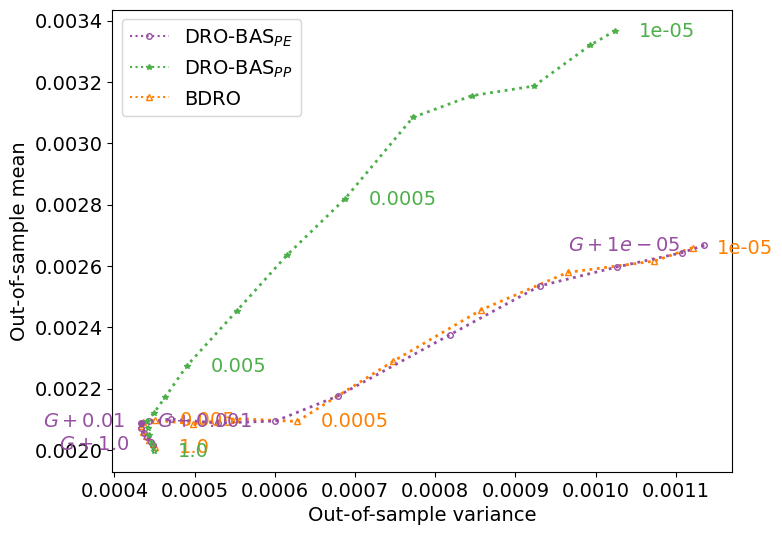

In [100]:
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = True
        offset=0.00003
        special_epsilons = [0.00001, 0.001, 0.01, 1.0]
    else:
        local_log_partition_constant = False
        offset=0.00003
        special_epsilons = [0.00001, 0.0005, 0.005, 1.0]
    mean_variance_plot(
        ax, group_df, is_labelled=True, offset=offset, alpha=1.0,
        **algorithm_inference_style(algorithm, inference, label_inference=False),
        special_epsilons=special_epsilons,
        add_log_partition_function=local_log_partition_constant, minimise=False
    )
    #  log_partition_constant=local_log_partition_constant
# handles, labels = ax.get_legend_handles_labels()
# order = [1,0]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend(fontsize=12)
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
# ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
handles, labels = ax.get_legend_handles_labels()
algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value]
order = [list(labels).index(a) for a in algorithm_order]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
fig.show()
# NOTE: this does not include transaction costs
# fig.savefig(f"{kl_experiment_dir_string}/{experiment_name}_mean_var_{filter_dgp}_{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf", bbox_inches="tight")

In [101]:
if compare_with_original:

    mean_variance_plot_data_dict = {}
    current_label = None
    lines = ax.get_lines()
    for i in range(len(lines)):
        line = lines[i]
        label = line.get_label()
        if label != "_nolegend_":
            current_label = label
        elif i == len(lines) - 1 or lines[i + 1].get_label() != "_nolegend_":
            x, y = line.get_xdata(), line.get_ydata()
            mean_variance_plot_data_dict[current_label] = {"x": x, "y": y}

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/mean_variance_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_mean_variance_plot_data_dict = pickle.load(f)

    assert old_mean_variance_plot_data_dict.keys() == mean_variance_plot_data_dict.keys()
    for key in old_mean_variance_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_mean_variance_plot_data_dict[key][coord], mean_variance_plot_data_dict[key][coord])

In [102]:
# TODO: refactor some of what's in this function with some of what's in the other "include_transaction_costs_in*" functions
def include_transaction_costs_in_dro_results(results_df, dro_algorithms_for_figure, kl_epsilon_list, num_replications, james_djia_data_path_string):
    for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
        if algorithm not in dro_algorithms_for_figure or epsilon not in kl_epsilon_list:
            continue
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        for i in range(num_replications):
            portfolio_returns_this_period = group_df["out_of_sample_cost"].values[i]
            # TODO: this whole thing with the use of get_window_of_train_and_test_dataframes is a bit of a fudge--the stock IDs should be saved along with the other results. Moreover, I don't know why I appended _{window index} to each of the FIGIs in the first place, so undo that and get rid of the splitting done below.
            stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
            portfolio_weighting = group_df["solution"].values[i]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
            portfolio_returns_this_period[0] -= transaction_cost
            results_df.at[group_df.index[i], "out_of_sample_cost"] = portfolio_returns_this_period

def include_transaction_costs_in_markowitz_results(markowitz_results_james_normal_runs_without_transaction_costs, markowitz_lambdas, james_djia_data_path_string):
    for item in markowitz_results_james_normal_runs_without_transaction_costs.items():
        risk_aversion_value, windows = item
        if risk_aversion_value not in markowitz_lambdas:
            continue
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        for i, window in enumerate(windows):
            out_of_sample_costs_for_window = list(window["out_of_sample_cost"])
            stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
            portfolio_weighting = window["portfolio_weighting"]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
            out_of_sample_costs_for_window[0] -= transaction_cost
            # NOTE: originally a numpy array or pandas series, now a python list
            markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i]["out_of_sample_cost"] = out_of_sample_costs_for_window

In [103]:
def calculate_dro_results_to_plot(dro_algorithms_for_figure, kl_algorithms, results_df, kl_epsilon_list, mmd_epsilon_list, weeks_for_risk_adjusted_metrics, num_replications, risk_free_rates, num_test_weeks, james_windows):

    dro_figure_data = {algorithm: {} for algorithm in dro_algorithms_for_figure}

    for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
        is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
        is_kl_experiment = algorithm in kl_algorithms

        if james_windows:
            if algorithm not in dro_algorithms_for_figure:
                continue

        if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
            cost_list = []
            sortino_ratios = []
            sharpe_ratios = []
            for i in range(num_replications):
                out_of_sample_returns_this_period = group_df["out_of_sample_cost"].values[i]
                cost_list += out_of_sample_returns_this_period
                weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]
                params_for_ratio = {"weekly_portfolio_returns": cost_list, "period_in_weeks": weeks_for_risk_adjusted_metrics}
                sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
                sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))
            dro_portfolio_returns = np.array(cost_list)

            results = {
                "sharpe_ratios": sharpe_ratios,
                "sortino_ratios": sortino_ratios,
                "dro_portfolio_returns": dro_portfolio_returns,
            }

            dro_figure_data[algorithm][epsilon] = results

    return dro_figure_data

def get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_map, num_replications):
    validation_kl_dro_figure_data = {}
    for ratio_type, results_df in ratio_type_to_kl_validation_results_df_map.items():
        validation_kl_dro_figure_data_for_ratio = {algorithm: {} for algorithm in dro_algorithms_for_figure}
        for algorithm, group_df in results_df.groupby("algorithm"):
            if algorithm not in dro_algorithms_for_figure:
                continue
            cost_list = []
            ratio_list = []
            for i in range(num_replications):
                cost_list += group_df["out_of_sample_cost"].values[i]
                ratio_list.append(group_df[ratio_type].values[i])
            validation_kl_dro_portfolio_returns = np.array(cost_list)
            results = {
                "portfolio_returns": validation_kl_dro_portfolio_returns,
                "ratios": ratio_list
            }
            validation_kl_dro_figure_data_for_ratio[algorithm] = results
        validation_kl_dro_figure_data[ratio_type] = validation_kl_dro_figure_data_for_ratio
    return validation_kl_dro_figure_data

def calculate_markowitz_normal_runs_results_to_plot(markowitz_results_james_normal_runs, markowitz_lambdas, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    markowitz_figure_data = {}

    for item in markowitz_results_james_normal_runs.items():
        risk_aversion_value, windows = item
        if risk_aversion_value not in markowitz_lambdas:
            continue
        markowitz_cost_list = []
        markowitz_sharpe_ratios = []
        markowitz_sortino_ratios = []
        for i, window in enumerate(windows):
            # TODO: note that, below, using list constructor because, if it doesn't go through include_transaction_costs_in_markowitz_results first, the out of sample costs in markowitz_results_james_normal_runs may not be Python lists
            out_of_sample_costs_for_window = list(window["out_of_sample_cost"])
            markowitz_cost_list += out_of_sample_costs_for_window
            weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]
            params_for_ratio = {"weekly_portfolio_returns": markowitz_cost_list, "period_in_weeks": weeks_for_risk_adjusted_metrics}
            markowitz_sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
            markowitz_sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))
        markowitz_portfolio_returns = np.array(markowitz_cost_list)

        results = {
            "markowitz_portfolio_returns": markowitz_portfolio_returns,
            "markowitz_sharpe_ratios": markowitz_sharpe_ratios,
            "markowitz_sortino_ratios": markowitz_sortino_ratios
        }

        markowitz_figure_data[risk_aversion_value] = results

    return markowitz_figure_data

def calculate_price_weighted_results_to_plot(index_returns_df, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics):

    price_weighted_portfolio_returns = list(index_returns_df.values)
    sharpe_ratios = []
    sortino_ratios = []
    for i in range(num_time_windows):
        weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]
        params_for_ratio = {"weekly_portfolio_returns": price_weighted_portfolio_returns[:(i+1)*num_test_weeks], "period_in_weeks": weeks_for_risk_adjusted_metrics}
        sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
        sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))

    price_weighted_figure_data = {
        "price_weighted_portfolio_returns": price_weighted_portfolio_returns,
        "price_weighted_sharpe_ratios": sharpe_ratios,
        "price_weighted_sortino_ratios": sortino_ratios
    }

    return price_weighted_figure_data

In [104]:
def calculate_potential_ratio_results(ratio, num_replications, hyperparameter_list, dro_results_df, markowitz_results_dict, algorithm, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    highest_ratios = []
    best_hyperparameters = []
    running_portfolio_returns = []
    for i in range(num_replications):
        highest_ratio_this_window = -float('inf')
        best_hyperparameter_this_window = None
        best_running_portfolio_returns = None
        for hyperparameter in hyperparameter_list:
            if algorithm == "markowitz":
                # TODO: note that, below, using list constructor because, if it doesn't go through include_transaction_costs_in_markowitz_results first, the out of sample costs in markowitz_results_james_normal_runs may not have been Python lists
                portfolio_returns_this_window_under_this_hyperparameter = list(markowitz_results_dict[hyperparameter][i]["out_of_sample_cost"])
            else:
                portfolio_returns_this_window_under_this_hyperparameter = dro_results_df[(dro_results_df["algorithm"] == algorithm) & (dro_results_df["epsilon"] == hyperparameter)]["out_of_sample_cost"].values[i]
            running_portfolio_returns_under_this_hyperparameter = running_portfolio_returns + portfolio_returns_this_window_under_this_hyperparameter
            ratio_calculator = {"sharpe": calculate_sharpe_ratio, "sortino": calculate_sortino_ratio}[ratio]
            ratio_this_window_under_this_hyperparameter = ratio_calculator(running_portfolio_returns_under_this_hyperparameter, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics)
            if ratio_this_window_under_this_hyperparameter > highest_ratio_this_window:
                highest_ratio_this_window = ratio_this_window_under_this_hyperparameter
                best_hyperparameter_this_window = hyperparameter
                best_running_portfolio_returns = running_portfolio_returns_under_this_hyperparameter
        highest_ratios.append(highest_ratio_this_window)
        best_hyperparameters.append(best_hyperparameter_this_window)
        running_portfolio_returns = best_running_portfolio_returns
    return {"highest_ratios": highest_ratios, "best_hyperparameters": best_hyperparameters}

def calculate_potential_dro_ratio_results(dro_algorithms_for_figure, num_replications, kl_epsilon_list, results_df, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    potential_results = {}

    for ratio in ("sharpe", "sortino"):

        potential_results_for_ratio = {}

        for algorithm in dro_algorithms_for_figure:

            potential_results_for_ratio[algorithm] = calculate_potential_ratio_results(ratio, num_replications, kl_epsilon_list, results_df, None, algorithm, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

        potential_results[ratio] = potential_results_for_ratio

    return potential_results

def calculate_potential_markowitz_ratio_results(num_replications, markowitz_lambdas, markowitz_results_james_normal_runs, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):
    
    potential_results = {}

    for ratio in ("sharpe", "sortino"):

        potential_results[ratio] = calculate_potential_ratio_results(ratio, num_replications, markowitz_lambdas, None, markowitz_results_james_normal_runs, "markowitz", risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    return potential_results

In [105]:
def process_markowitz_validation_results_to_plot(markowitz_results_james_validation_with_transaction_costs):

    processed_results = {}

    for ratio_type, windows in markowitz_results_james_validation_with_transaction_costs.items():
        processed_results[ratio_type] = [window[ratio_type] for window in windows]

    return processed_results

In [106]:
if james_windows:
    num_time_windows = len(windows)
else:
    num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
    last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])

kl_epsilon_list = [
    0.00001,
    0.001,
    1.0
]
mmd_epsilon_list = [0.0001, 0.01, 0.2]
kl_algorithms = ("kl_dro_bas", "kl_pp", "kl_bdro")

dro_algorithms_for_figure = (
    "kl_bdro",
    "kl_pp",
    "kl_dro_bas",
)

weeks_for_risk_adjusted_metrics = 156
rebalance_periods_for_risk_adjusted_metrics = int(weeks_for_risk_adjusted_metrics / num_test_weeks)

markowitz_lambdas = (
    0.5,
    5,
    50,
    500
)

if include_transaction_costs:

    include_transaction_costs_in_dro_results(results_df, dro_algorithms_for_figure, kl_epsilon_list, num_replications, james_djia_data_path_string)
    include_transaction_costs_in_markowitz_results(markowitz_results_james_normal_runs, markowitz_lambdas, james_djia_data_path_string)
    # NOTE: the results in ratio_type_to_kl_validation_results_df_maps, specifically the out_of_sample_cost details, already feature transaction costs

# dro_figure_data = calculate_dro_results_to_plot(dro_algorithms_for_figure, kl_algorithms, results_df, kl_epsilon_list, mmd_epsilon_list, weeks_for_risk_adjusted_metrics, num_replications, risk_free_rates, num_test_weeks, james_windows)

if james_windows:

    # potential_dro_ratio_results = calculate_potential_dro_ratio_results(dro_algorithms_for_figure, num_replications, kl_epsilon_list, results_df, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    # markowitz_normal_runs_figure_data = calculate_markowitz_normal_runs_results_to_plot(markowitz_results_james_normal_runs, markowitz_lambdas, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    # potential_markowitz_ratio_results = calculate_potential_markowitz_ratio_results(num_replications, markowitz_lambdas, markowitz_results_james_normal_runs, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    # markowitz_shv_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_shv_with_tcosts_in_results)

    # markowitz_shv_figure_data_with_tcosts_in_cost_function = process_markowitz_validation_results_to_plot(markowitz_results_shv_with_tcosts_in_results_and_cost_function)

    # markowitz_rolling_validation_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_rolling_validation_with_tcosts_in_results)

    price_weighted_figure_data = calculate_price_weighted_results_to_plot(index_returns_df, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics)

    # shv_dro_figure_data = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps["shv"], num_replications)

    # rolling_validation_dro_figure_data = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps["rolling_validation"], num_replications)

    markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function)

    rolling_validation_dro_figure_data_tcost_optimisation = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps_tcost_optimisation["rolling_validation"], num_replications)

In [107]:
def _get_oos_weeks():
    start_date = dt.date(2008, 2, 27)   # NOTE: first test date
    end_date = dt.date(2025, 7, 30) # NOTE: last test date
    oos_weeks = []
    current = start_date
    while current <= end_date:
        oos_weeks.append(current)
        current += dt.timedelta(weeks=1)
    return oos_weeks

def _set_up_plot(oos_weeks, y_type, min_y, max_y):

    fig, ax = plt.subplots(figsize=(16,9))

    first_training_week = min(oos_weeks) - dt.timedelta(weeks=52)
    ax.set_xlim(first_training_week, max(oos_weeks) + dt.timedelta(weeks=52))
    ax.vlines(min(oos_weeks), -10, 10, color="black", linestyle=":")
    ax.set_xlabel("Date")

    ylabel = f"Out-of-sample {y_type}"
    ax.set_ylabel(ylabel)
    ax.set_ylim(min_y, max_y)

    return fig, ax

def _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs):
    figure_save_file = f"{kl_experiment_dir_string}/{experiment_name}_{plot_type}_"
    if include_transaction_costs:
        figure_save_file += "transaction_costs_"
    figure_save_file += f"{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"
    return figure_save_file

def _plot_price_weighted_data(ax, x_data, price_weighted_data):
    ax.plot(
        x_data,
        price_weighted_data,
        label="DJIA Total Return Index",    # TODO: reconsider this might not be the best label, although you can always redefine it in the dissertation
        color="#a65628"
    )

def plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save, min_y, max_y):

    oos_weeks = _get_oos_weeks()

    fig, ax = _set_up_plot(oos_weeks, "cumulative return", min_y, max_y)

    plot_type = f"avg_returns_{algorithm}"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    for epsilon in kl_epsilon_list:

        dro_portfolio_returns = dro_figure_data[algorithm][epsilon]["dro_portfolio_returns"]

        if algorithm == "kl_dro_bas":
            label = AlgorithmName[algorithm].value + " ($G +" + str(epsilon) + "$)"
        else:
            label = AlgorithmName[algorithm].value + f" (${epsilon}$)"

        epsilon_to_linestyle = {
            0.00001: "dotted",
            0.001: "dashed",
            1.0: "solid"
        }

        ax.plot(
            oos_weeks,
            np.cumsum(dro_portfolio_returns),
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
            linestyle=epsilon_to_linestyle[epsilon],
        )

    _plot_price_weighted_data(ax, oos_weeks, np.cumsum(price_weighted_figure_data["price_weighted_portfolio_returns"]))

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_ratios_for_best_hyperparameters_against_price_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, markowitz_normal_runs_figure_data, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, algorithm_best_hyperparameter_map, AlgorithmName, AlgorithmColor, save):

    oos_weeks = _get_oos_weeks()

    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)

    plot_type = f"{ratio_type.capitalize()}_ratios_under_single_best_hyperparameter_for_each_optimiser"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    for algorithm in dro_figure_data.keys():

        epsilon = algorithm_best_hyperparameter_map[algorithm]

        ratios = dro_figure_data[algorithm][epsilon][f"{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

        if algorithm == "kl_dro_bas":
            label = AlgorithmName[algorithm].value + " ($G +" + str(epsilon) + "$)"
        else:
            label = AlgorithmName[algorithm].value + f" (${epsilon}$)"

        ax.plot(
            x_data,
            ratios,
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
        )

    risk_aversion = algorithm_best_hyperparameter_map["markowitz"]

    markowitz_ratios = markowitz_normal_runs_figure_data[risk_aversion][f"markowitz_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    ax.plot(
        x_data,
        markowitz_ratios,
        label=f"Markowitz (λ = {risk_aversion})",
        alpha=0.8,
        color="blue",
    )

    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

# TODO: Function for plotting Sharpe ratios for one DRO algorithm under different hyperparameters in the same plot
# TODO: Function for plotting Sortino ratios for one DRO algorithm under different hyperparameters in the same plot
# TODO: Function for plotting cumulative returns for Markowitz (against portfolio-weighted approach) under different hyperparameters in the same plot
# TODO: Function for plotting Sharpe ratios for Markowitz under different hyperparameters in the same plot
# TODO: Function for plotting Sortino ratios for Markowitz under different hyperparameters in the same plot

def plot_potential_ratios_for_dro_algorithms_and_markowitz_against_portfolio_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, potential_markowitz_ratio_results, AlgorithmName, AlgorithmColor, save, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics):

    assert ratio_type in ("sharpe", "sortino")

    # TODO: don't forget about displaying hyperparameter in each window if beneficial

    oos_weeks = _get_oos_weeks()

    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)

    plot_type = f"potential_{ratio_type.capitalize()}_ratios"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    potential_dro_ratios = potential_dro_ratio_results[ratio_type]

    for algorithm in potential_dro_ratios:

        ratios = potential_dro_ratios[algorithm]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

        label = AlgorithmName[algorithm].value + " (Potential)"

        ax.plot(
            x_data,
            ratios,
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
        )

    potential_markowitz_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    label = "Markowitz (Potential)"

    ax.plot(
        x_data,
        potential_markowitz_ratios,
        label=label,
        alpha=0.8,
        color="blue",
    )

    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file):
    # TODO: don't forget about displaying hyperparameter in each window if beneficial
    oos_weeks = _get_oos_weeks()
    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)
    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]
    ax.plot(
        x_data,
        potential_ratios,
        label=f"{algorithm_name_pretty} (Potential)",
        alpha=0.8,
        color=algorithm_color,
    )
    for validation_type, ratios in ratios_for_each_validation_type.items():
        ax.plot(
            x_data,
            ratios,
            label=f"{algorithm_name_pretty} ({'SHV' if validation_type == 'shv' else 'Rolling Validation'})",
            alpha=0.8,
            color=algorithm_color,
            linestyle={"shv": "dashed", "rolling_validation": "dotted"}[validation_type]
        )
    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])
    ax.legend(ncol=2)
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_ratios_for_single_holdout_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name_shv, include_transaction_costs, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratio_results, algorithm, AlgorithmName, AlgorithmColor, shv_dro_figure_data, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save):

    plot_type = f"potential_vs_shv_{ratio_type.capitalize()}_{algorithm}"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name_shv, plot_type, include_transaction_costs)

    potential_dro_ratios = potential_dro_ratio_results[rebalance_periods_for_risk_adjusted_metrics-1:]

    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    shv_ratios = shv_dro_figure_data[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratios, algorithm_name_pretty, algorithm_color, {"shv": shv_ratios}, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file)

# TODO: refactor aspects of the below that are worth refactoring with their Markowitz counterparts, following the NOTEs to help you perform the refactor
def plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, save, dro_validation_figure_data):

    plot_type = "potential_"
    for validation_type in dro_validation_figure_data.keys():
        plot_type += f"vs_{validation_type}_"
    plot_type += ratio_type.capitalize()
    plot_type += f"_{algorithm}"    # NOTE: not present in Markowitz counterpart of this function

    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)  # NOTE: very different in Markowitz counterpart of this function

    potential_dro_ratios = potential_dro_ratio_results[rebalance_periods_for_risk_adjusted_metrics-1:]  # NOTE: the bit before the brackets is different in the Markowitz counterpart of this function, as is the variable name

    # NOTE: the RHS in the below assignments is different in the Markowitz counterpart of this function
    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    ratios_for_each_validation_type = {validation_type: figure_data[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:] for validation_type, figure_data in dro_validation_figure_data.items()}  # NOTE: the Markowitz counterpart doesn't have [algorithm]["ratios"] here

    # NOTE: the only thing below different from Markowitz counterpart of this function is that I have called the variable potential_dro_ratios rather than potential_markowitz_ratios
    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file)

def _get_figure_save_file_just_markowitz(plot_type, include_transaction_costs):

    figure_save_file = f"/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/{plot_type}_"
    if include_transaction_costs:
        figure_save_file += "transaction_costs_in_results"
    figure_save_file += f"{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"

    return figure_save_file

def plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, markowitz_validation_figure_data, save):
    """markowitz_validation_figure_data should look like {"shv": markowitz_shv_figure_data, "rolling_validation": markowitz_rolling_validation_figure_data}, for example, but it needs not have both entries"""

    plot_type = "potential_"
    for validation_type in markowitz_validation_figure_data.keys():
        plot_type += f"vs_{validation_type}_"
    plot_type += ratio_type.capitalize()

    figure_save_file = _get_figure_save_file_just_markowitz(plot_type, True)

    potential_markowitz_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    algorithm_name_pretty = "Markowitz"
    algorithm_color = "blue"

    ratios_for_each_validation_type = {validation_type: figure_data[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:] for validation_type, figure_data in markowitz_validation_figure_data.items()}

    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file)

def plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_experiment_dir_string, experiment_name, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, validation_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, validation_type, includes_tcost_optimisation):
    # TODO: don't forget about displaying hyperparameter in each window if beneficial
    plot_type = f"{validation_type}_"
    if includes_tcost_optimisation:
        plot_type += "tcost_optimisation"
    plot_type += f"{ratio_type.capitalize()}_ratios"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, True)
    oos_weeks = _get_oos_weeks()
    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)
    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]
    label_addend = "" if includes_tcost_optimisation else f" ({'SHV' if validation_type == 'shv' else 'Rolling Validation'})"
    for algorithm in dro_algorithms_for_figure:
        ratios_for_dro_algorithm = validation_dro_figure_data[ratio_type][algorithm]["ratios"]
        algorithm_name_pretty = AlgorithmName[algorithm]
        algorithm_color = AlgorithmColor[algorithm]
        ax.plot(
            x_data,
            ratios_for_dro_algorithm[rebalance_periods_for_risk_adjusted_metrics-1:],
            label=algorithm_name_pretty+label_addend,
            alpha=0.8,
            color=algorithm_color
        )
    ax.plot(
        x_data,
        markowitz_validation_figure_data[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:],
        label="Markowitz"+label_addend,
        alpha=0.8,
        color="blue"
    )
    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])
    ax.legend(ncol=2)
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color):

    # NOTE: now passing in figure_save_file, so make sure they are right before calling this function

    oos_weeks = _get_oos_weeks()
    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)
    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    # NOTE: now passing in algorithm_name_pretty and algorithm_color, so make sure they are right before calling this function

    # NOTE: now passing in ratios_without_tcost_optimisation and ratios_with_tcost_optimisation, so make sure they are right before calling this function

    for has_tcost_optimsation in (False, True):
        ax.plot(
            x_data,
            ratios_with_tcost_optimisation if has_tcost_optimsation else ratios_without_tcost_optimisation,
            label=f"{algorithm_name_pretty} (Rolling Validation with{'' if has_tcost_optimsation else 'out'} Transaction Cost Optimisation)",
            alpha=0.8,
            color=algorithm_color,
            linestyle="dashdot" if has_tcost_optimsation else "dotted"  # TODO: you used dashdot for one of the Markowitz normal runs, so consider using something else here, although I expect it's no big deal
        )
    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])
    ax.legend(ncol=2)
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, figure_data_without_tcost_optimisation, figure_data_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save):

    plot_type = f"rolling_validation_with_and_without_transaction_cost_optimisation_{ratio_type.capitalize()}"
    figure_save_file = _get_figure_save_file_just_markowitz(plot_type, True)

    algorithm_name_pretty = "Markowitz"
    algorithm_color = "blue"

    ratios_without_tcost_optimisation = figure_data_without_tcost_optimisation[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:]
    ratios_with_tcost_optimisation = figure_data_with_tcost_optimisation[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:]

    _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color)

def plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_dro_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, rolling_validation_dro_figure_data_without_tcost_optimisation, rolling_validation_dro_figure_data_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, algorithm, kl_experiment_dir_string, AlgorithmName, AlgorithmColor):

    plot_type = f"rolling_validation_with_and_without_transaction_cost_optimisation_{ratio_type.capitalize()}"
    plot_type += f"_{algorithm}"

    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, "", plot_type, True)

    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    ratios_without_tcost_optimisation = rolling_validation_dro_figure_data_without_tcost_optimisation[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]
    ratios_with_tcost_optimisation = rolling_validation_dro_figure_data_with_tcost_optimisation[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color)

In [ ]:
# for algorithm in dro_algorithms_for_figure:
#     min_y, max_y = {
#         "kl_bdro": (-1.1, 2.8),
#         "kl_pp": (...),
#         "kl_dro_bas": (...)
#     }[algorithm]
    # plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, "kl_bdro", dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save=False, min_y=min_y, max_y=max_y)

for ratio_type in ("sharpe", "sortino"):
    min_y, max_y = {
        "sharpe": (0, 0.24),
        "sortino": (0, 0.4)
    }[ratio_type]
    algorithm_best_hyperparameter_map = {
        "kl_bdro": 1,
        "kl_pp": 1,
        "kl_dro_bas": 1,
        "markowitz": 500
    }
    # plot_ratios_for_best_hyperparameters_against_price_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, markowitz_normal_runs_figure_data, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, algorithm_best_hyperparameter_map, AlgorithmName, AlgorithmColor, True)

for ratio_type in ("sharpe", "sortino"):
    min_y, max_y = {
        "sharpe": (-0.04, 0.33),
        "sortino": (-0.08, 0.63)
    }[ratio_type]
    # plot_potential_ratios_for_dro_algorithms_and_markowitz_against_portfolio_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, potential_markowitz_ratio_results, AlgorithmName, AlgorithmColor, False, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics)

for algorithm in dro_algorithms_for_figure:
    for ratio_type in ("sharpe", "sortino"):
        min_y, max_y = {
            "sharpe": {
                "kl_bdro": (-0.09, 0.31),
                "kl_pp": (-0.06, 0.3),
                "kl_dro_bas": (-0.1, 0.31)
            },
            "sortino": {
                "kl_bdro": (-0.11, 0.55),
                "kl_pp": (-0.07, 0.55),
                "kl_dro_bas": (-0.12, 0.56)
            }
        }[ratio_type][algorithm]
        # DRO SHV vs potential vs price-weighted
        # plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_validation_experiment_dirs_map["shv"][ratio_type], experiment_name_shv, True, potential_dro_ratio_results[ratio_type][algorithm]["highest_ratios"], rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, False, {"shv": shv_dro_figure_data})

for ratio_type in ("sharpe", "sortino"):
    min_y, max_y = {
        "sharpe": (-0.07, 0.33),
        "sortino": (-0.1, 0.63)
    }[ratio_type]
    # Markowitz SHV vs potential vs price-weighted
    # plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, {"shv": markowitz_shv_figure_data}, False)

for ratio_type in (
    "sharpe",
    "sortino",
):
    min_y, max_y = {
        "sharpe": (-0.09, 0.22),
        "sortino": (-0.13, 0.39)
    }[ratio_type]
    # SHV for DRO and Markowitz vs price-weighted
    # plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map["shv"][ratio_type], experiment_name_shv, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, shv_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_shv_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "shv", False)

for algorithm in dro_algorithms_for_figure:
    for ratio_type in ("sharpe", "sortino"):
        min_y, max_y = {
            "sharpe": {
                "kl_bdro": (-0.09, 0.31),
                "kl_pp": (-0.06, 0.3),
                "kl_dro_bas": (-0.11, 0.31)
            },
            "sortino": {
                "kl_bdro": (-0.11, 0.55),
                "kl_pp": (-0.09, 0.55),
                "kl_dro_bas": (-0.13, 0.56)
            }
        }[ratio_type][algorithm]
        # DRO SHV vs rolling validation vs potential vs price-weighted
        # plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_validation_experiment_dirs_map["rolling_validation"][ratio_type], experiment_name_rolling_validation, True, potential_dro_ratio_results[ratio_type][algorithm]["highest_ratios"], rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, False, {"shv": shv_dro_figure_data, "rolling_validation": rolling_validation_dro_figure_data})

for ratio_type in ("sharpe", "sortino"):
    min_y, max_y = {
        "sharpe": (-0.07, 0.33),
        "sortino": (-0.1, 0.63)
    }[ratio_type]
    # Markowitz SHV vs rolling validation vs potential vs price-weighted
    # plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, {"shv": markowitz_shv_figure_data, "rolling_validation": markowitz_rolling_validation_figure_data}, False)

for ratio_type in (
    "sharpe",
    "sortino",
):
    min_y, max_y = {
        "sharpe": (-0.11, 0.22),
        "sortino": (-0.13, 0.34)
    }[ratio_type]
    # Rolling validation (without tcost optimisation) for DRO and Markowitz vs price-weighted
    # plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map["rolling_validation"][ratio_type], experiment_name_rolling_validation, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, rolling_validation_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_rolling_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "rolling_validation", False)

for algorithm in dro_algorithms_for_figure:
    for ratio_type in ("sharpe", "sortino"):
        min_y, max_y = {
            "sharpe": {
                "kl_bdro": (-0.09, 0.31),
                "kl_pp": (-0.04, 0.27),
                "kl_dro_bas": (-0.11, 0.23)
            },
            "sortino": {
                "kl_bdro": (-0.11, 0.55),
                "kl_pp": (-0.08, 0.44),
                "kl_dro_bas": (-0.13, 0.4)
            }
        }[ratio_type][algorithm]
        # DRO rolling validation with vs without tcost optimisation vs price-weighted
        # TODO: when you are ready for BDRO, only save that, as you've already saved and uploaded for the other DRO algorithms
        # plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_dro_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, rolling_validation_dro_figure_data, rolling_validation_dro_figure_data_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, algorithm, kl_validation_experiment_dirs_map_tcost_optimisation["rolling_validation"][ratio_type], AlgorithmName, AlgorithmColor)

for ratio_type in (
    "sharpe",
    "sortino",
):
    min_y, max_y = {
        "sharpe": (-0.07, 0.22),
        "sortino": (-0.1, 0.34)
    }[ratio_type]
    # Markowitz rolling validation with vs without tcost optimisation vs price-weighted
    # plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, markowitz_rolling_validation_figure_data, markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False)

for ratio_type in (
    "sharpe",
    "sortino",
):
    min_y, max_y = {
        "sharpe": (-0.08, 0.24),
        "sortino": (-0.11, 0.38)
    }[ratio_type]
    # Rolling validation with tcost optimisation for DRO and Markowitz vs price-weighted
    # TODO: only save when you can include BDRO
    # plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map_tcost_optimisation["rolling_validation"][ratio_type], "", min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, rolling_validation_dro_figure_data_tcost_optimisation, AlgorithmName, AlgorithmColor, markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "rolling_validation", True)

# TODO: complete the rest of the functions and call them here

In [109]:
if not james_windows:

    fig, ax = plt.subplots(figsize=(16,9))

    if james_windows:
        start_date = dt.date(2008, 2, 27)   # NOTE: first test date
        end_date = dt.date(2025, 7, 30) # NOTE: last test date
        oos_weeks = []
        current = start_date
        while current <= end_date:
            oos_weeks.append(current)
            current += dt.timedelta(weeks=1)
    else:
        oos_weeks = [IN_SAMPLE_TIME_WINDOW + i for i in range(OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows)]

    # y_type = "cumulative return"
    # y_type = "Sharpe ratio"
    y_type = "Sortino ratio"

    figure_name_addend = ""
    if len(dro_algorithms_for_figure) == 1:
        figure_name_addend += "_" + dro_algorithms_for_figure[0]
    if len(kl_epsilon_list) == 1:
        figure_name_addend += "_epsilon_" + str(kl_epsilon_list[0])
    figure_name = f"{kl_experiment_dir_string}/{experiment_name}_{y_type.replace(' ', '_')}_{filter_dgp}{figure_name_addend}"

    plot_markowitz = False
    plot_price_weighted_benchmark = False

    x_map = {
        "cumulative return": oos_weeks,
        "Sharpe ratio": oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks],
        "Sortino ratio": oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks],
    }

    for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
        is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
        is_kl_experiment = algorithm in kl_algorithms

        if james_windows:
            if algorithm not in dro_algorithms_for_figure:
                continue

        if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):

            dro_portfolio_returns = dro_figure_data[algorithm][epsilon]["dro_portfolio_returns"]
            sharpe_ratios = dro_figure_data[algorithm][epsilon]["sharpe_ratios"]
            sortino_ratios = dro_figure_data[algorithm][epsilon]["sortino_ratios"]
            
            if algorithm == "kl_dro_bas":
                label = AlgorithmName[algorithm].value + " ($G +" + str(epsilon) + "$)"
            else:
                label = AlgorithmName[algorithm].value + f" (${epsilon}$)"
            is_robas_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
            idx = mmd_epsilon_list.index(epsilon) if is_robas_experiment else kl_epsilon_list.index(epsilon)

            y_map = {
                "cumulative return": np.cumsum(dro_portfolio_returns),
                "Sharpe ratio": sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
                "Sortino ratio": sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
            }

            ax.plot(
                x_map[y_type],
                y_map[y_type],
                label=label,
                alpha=0.8,
                color=AlgorithmColor[algorithm].value,
                linestyle=["dotted" , "dashed" , "solid"][idx],
            )

    if james_windows:

        if plot_markowitz:

            markowitz_lambda_line_style_map = {
                0.5: "dotted",
                5: "dashdot",
                50: "dashed",
                500: "solid",
            }

            for risk_aversion_value in markowitz_lambda_line_style_map:

                markowitz_portfolio_returns = markowitz_normal_runs_figure_data[risk_aversion_value]["markowitz_portfolio_returns"]
                markowitz_sharpe_ratios = markowitz_normal_runs_figure_data[risk_aversion_value]["markowitz_sharpe_ratios"]
                markowitz_sortino_ratios = markowitz_normal_runs_figure_data[risk_aversion_value]["markowitz_sortino_ratios"]

                # markowitz_sortino_ratios = potential_markowitz_ratio_results["sortino"]["highest_ratios"]

                markowitz_label = f"Markowitz (λ = {risk_aversion_value})"

                y_map = {
                    "cumulative return": np.cumsum(markowitz_portfolio_returns),
                    "Sharpe ratio": markowitz_sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
                    "Sortino ratio": markowitz_sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:]
                }

                ax.plot(
                    x_map[y_type],
                    y_map[y_type],
                    label=markowitz_label,
                    alpha=0.8,
                    color="blue",
                    linestyle=markowitz_lambda_line_style_map[risk_aversion_value]
                )

            if len(dro_algorithms_for_figure) == 0:
                figure_name = f"/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/markowitz_{y_type.replace(' ', '_')}"

        if plot_price_weighted_benchmark:

            price_weighted_portfolio_returns = price_weighted_figure_data["price_weighted_portfolio_returns"]
            sharpe_ratios = price_weighted_figure_data["price_weighted_sharpe_ratios"]
            sortino_ratios = price_weighted_figure_data["price_weighted_sortino_ratios"]

            y_map = {
                "cumulative return": np.cumsum(price_weighted_portfolio_returns),
                "Sharpe ratio": sharpe_ratios[rebalance_periods_for_risk_adjusted_metrics-1:],
                "Sortino ratio": sortino_ratios[rebalance_periods_for_risk_adjusted_metrics-1:]
            }

            ax.plot(
                x_map[y_type],
                y_map[y_type],
                label="DJIA Total Return Index",    # TODO: reconsider this might not be the best label, although you can always redefine it in the dissertation
                color="#a65628"
            )

    CB_color_cycle = ['#4daf4a', '#f781bf', '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']
    if not james_windows:
        index_returns_axis = np.cumsum(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW: IN_SAMPLE_TIME_WINDOW + OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows].values)
        ax.plot(oos_weeks, index_returns_axis, label=f"{dgp} Index", color="#a65628")

        for i, baseline_model in enumerate(["MeanVar"]):
            baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
            baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
            baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
            baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
            baseline_returns = np.loadtxt(baseline_returns_txt)
            ax.plot(oos_weeks, np.cumsum(baseline_returns[:OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

    if james_windows:
        first_training_week = min(oos_weeks) - dt.timedelta(weeks=52)
        ax.set_xlim(first_training_week, max(oos_weeks) + dt.timedelta(weeks=52))
        ax.vlines(min(oos_weeks), -10, 10, color="black", linestyle=":")
        ax.set_xlabel("Date")
    else:
        ax.vlines(52, -0.3, 4.6, color="black", linestyle=":")
        ax.set_xlabel("Week number")

    figure_save_file = f"{figure_name}_"
    if include_transaction_costs:
        figure_save_file += "transaction_costs_"
    figure_save_file += f"{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"

    ylabel = f"Out-of-sample {y_type}"
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.1, 0.4)
    ax.legend(ncol=2) 
    # plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

In [110]:
if compare_with_original:

    cumulative_returns_plot_data_dict = {}

    for line in ax.get_lines():

        cumulative_returns_plot_data_dict[line.get_label()] = {
            "x": line.get_xdata(),
            "y": line.get_ydata()
        }

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/cumulative_returns_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_cumulative_returns_plot_data_dict = pickle.load(f)

    assert old_cumulative_returns_plot_data_dict.keys() == cumulative_returns_plot_data_dict.keys()
    for key in old_cumulative_returns_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_cumulative_returns_plot_data_dict[key][coord], cumulative_returns_plot_data_dict[key][coord])

### James: NOTE: haven't adapted the below cell to kl_portfolio_james

In [111]:
# # is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
# # is_kl_experiment = algorithm in ("kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical")
# # if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
# row_list = []
# for (algorithm, epsilon), group_df in results_df.loc[results_df["algorithm"].isin(kl_algorithms)].groupby(["algorithm", "epsilon"]):
#     if (algorithm in kl_algorithms and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
#         cost_list = []
#         for i in range(num_replications):
#             cost_list += group_df["out_of_sample_cost"].values[i]
#         row_list.append({"cumulative_return": np.sum(cost_list), "epsilon": epsilon, "algorithm": algorithm})
# cum_return_df = pd.DataFrame(row_list).set_index(["algorithm", "epsilon"])
# cum_return_df = cum_return_df.reindex(pd.MultiIndex.from_arrays([np.repeat(kl_algorithms, len(kl_epsilon_list)), np.tile(kl_epsilon_list, len(kl_algorithms))], names=["algorithm", "epsilon"]))
# # solve_time_df.reindex(pd.MultiIndex.from_product(np.repeat(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"], 3), solve_time_df.index.get_level_values("num_total_samples"), names=['algorithm', 'num_total_samples']))
# print(cum_return_df.unstack(level="algorithm").to_latex())
# # cum_return_df

In [112]:
if james_windows:
    epsilon_filtered_results_df = results_df[results_df["epsilon"].isin(kl_epsilon_list)]

    time_df = get_agg_df(
        epsilon_filtered_results_df,
        ["algorithm", "epsilon"]
    )[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

    # print(time_df)

    decimal_places = 3  # TODO: dynamically load this into the format strings below, if possible
    time_df["str_sample_time"] = time_df[["mean_sample_time", "std_sample_time"]].apply(
        lambda x: "{:.3f}".format(np.round(10**2 * x["mean_sample_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(10**2 * x["std_sample_time"], decimal_places)) + ")", axis=1
    )

    time_df["str_solve_time"] = time_df[["mean_solve_time", "std_solve_time"]].apply(
        lambda x: "{:.3f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
    )

    print(time_df)

    time_df = time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
    time_df.index = time_df.index.map(lambda x: AlgorithmName[x].value)
    # print(time_df[["str_solve_time", "str_sample_time"]].to_latex())

    for risk_aversion in list(markowitz_results_james_normal_runs.keys()):
        solve_times = [window['solve_time'] for window in markowitz_results_james_normal_runs[risk_aversion]]
        print(f'For a lambda of {risk_aversion}, mean and std of solve times (s) are {np.mean(solve_times)} and {np.std(solve_times)} respectively.')

else:

    time_df = get_agg_df(results_df, ["algorithm"])[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

    decimal_places = 2
    time_df["str_solve_time"] = time_df[["mean_solve_time", "std_solve_time"]].apply(
        lambda x: "{:.2f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
    )
    time_df["str_sample_time"] = time_df[["mean_sample_time", "std_sample_time"]].apply(
        lambda x: "{:.2f}".format(np.round(1000 * x["mean_sample_time"], decimal_places)) + " (" + "{:.2f}".format(np.round(1000 * x["std_sample_time"], decimal_places)) + ")", axis=1
    )
    time_df = time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
    time_df.index = time_df.index.map(lambda x: AlgorithmName[x].value)
    print(time_df[["str_solve_time", "str_sample_time"]].to_latex())

                    mean_solve_time  std_solve_time  mean_sample_time  \
algorithm  epsilon                                                      
kl_bdro    0.00001         5.467449        0.346509          0.036447   
           0.00100         4.249667        0.757311          0.033443   
           1.00000         5.398451        0.335152          0.038207   
kl_dro_bas 0.00001         0.011781        0.020271          0.000452   
           0.00100         0.012072        0.002128          0.000910   
           1.00000         0.011046        0.002246          0.000830   
kl_pp      0.00001         2.455794        0.382296          0.003870   
           0.00100         2.225305        0.161835          0.004204   
           1.00000         1.424257        0.021123          0.003146   

                    std_sample_time str_sample_time str_solve_time  
algorithm  epsilon                                                  
kl_bdro    0.00001         0.004370   3.645 (0.437)  5.467

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:237: FutureWarning: The provided callable <function mean at 0x7fbc6866cfe0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:237: FutureWarning: The provided callable <function std at 0x7fbc6866d120> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(**agg_dict)


In [113]:
# TODO: refactor with previous cell

def print_times_for_kl_dro_with_validation(ratio_type_to_results_df_map) -> None:

    kl_results_both_ratios_df = pd.concat(list(ratio_type_to_results_df_map.values()))
    time_df = get_agg_df(kl_results_both_ratios_df, ["algorithm"], temporal_validation=True)[["mean_total_solve_time", "std_total_solve_time", "mean_total_sample_time", "std_total_sample_time"]]

    decimal_places = 3
    time_df["str_total_sample_time"] = time_df[["mean_total_sample_time", "std_total_sample_time"]].apply(
        lambda x: "{:.3f}".format(np.round(10**2 * x["mean_total_sample_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(10**2 * x["std_total_sample_time"], decimal_places)) + ")", axis=1
    )

    time_df["str_total_solve_time"] = time_df[["mean_total_solve_time", "std_total_solve_time"]].apply(
        lambda x: "{:.3f}".format(np.round(x["mean_total_solve_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(x["std_total_solve_time"], decimal_places)) + ")", axis=1
    )

    print(time_df)

def print_times_for_markowitz_with_validation(markowitz_results_validation_with_tcosts_in_results) -> None:

    markowitz_windows_both_ratios = markowitz_results_validation_with_tcosts_in_results["sharpe"] + markowitz_results_validation_with_tcosts_in_results["sortino"]
    markowitz_total_solve_times = [window["time_for_hyperparameter_optimisation_and_running_with_best_one"] for window in markowitz_windows_both_ratios]
    
    print(f'For Markowitz, mean and std of solve times (s) are {np.mean(markowitz_total_solve_times)} and {np.std(markowitz_total_solve_times)} respectively.\n')

if james_windows:

    # print("\n=== SINGLE HOLDOUT VALIDATION ===\n")

    # print_times_for_kl_dro_with_validation(ratio_type_to_kl_validation_results_df_maps["shv"])

    # print_times_for_markowitz_with_validation(markowitz_results_shv_with_tcosts_in_results)


    print("\n=== ROLLING TEMPORAL VALIDATION WITHOUT TRANSACTION COST OPTIMISATION ===\n")

    # print_times_for_kl_dro_with_validation(ratio_type_to_kl_validation_results_df_maps["rolling_validation"])

    print_times_for_markowitz_with_validation(markowitz_results_rolling_validation_with_tcosts_in_results)

    print("\n=== ROLLING TEMPORAL VALIDATION WITHOUT TRANSACTION COST OPTIMISATION ===\n")

    ...

    print_times_for_markowitz_with_validation(markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function)


=== ROLLING TEMPORAL VALIDATION WITHOUT TRANSACTION COST OPTIMISATION ===

For Markowitz, mean and std of solve times (s) are 2.9115279071428573 and 0.48312366440802856 respectively.


=== ROLLING TEMPORAL VALIDATION WITHOUT TRANSACTION COST OPTIMISATION ===

For Markowitz, mean and std of solve times (s) are 3.471268764285714 and 0.5979595820619915 respectively.



### James: NOTE: haven't adapted any of the below cells to kl_portfolio_james

In [114]:
# bas_returns = []
# bdro_returns = []
# filter_epsilon = 0.1
# for (algorithm, epsilon), group_df in gb:
#     # dro_returns = group_df[week_cols].values.flatten()
#     if algorithm == "kl_dro_bas" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bas_returns += group_df["out_of_sample_cost"].values[i]
#     if algorithm == "kl_bdro" and epsilon == filter_epsilon:
#         assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
#         for i in range(num_replications):
#             bdro_returns += group_df["out_of_sample_cost"].values[i]
# plt.hist(bas_returns, bins=50, label="BAS", alpha=0.5)
# plt.hist(bdro_returns, bins=50, label="BDRO", alpha=0.5)
# plt.legend()

In [115]:
# from mis_dro.dataset import portfolio_dataset

# # training_time_window_id = 75
# training_time_window_id = 79
# out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW
# data, data_eval = portfolio_dataset("DowJones-crash", training_time_window_id, mmc2_dir, out_of_sample_time_window=out_of_sample_time_window)
# dim = data.shape[1]
# sol = np.ones(dim) / float(dim)
# data.shape, data_eval.shape

In [116]:
# start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
# end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
# test_start = end_training_week
# test_end = test_start + out_of_sample_time_window
# total_training_returns = (data @ sol).sum()

# plt.plot(oos_weeks[start_training_week- IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_end].values), label=f"Out-of-sample {dgp} Index", color=CB_color_cycle[0], linestyle="dotted")
# plt.plot(oos_weeks[start_training_week- IN_SAMPLE_TIME_WINDOW:test_start - IN_SAMPLE_TIME_WINDOW], np.cumsum(index_returns_df.iloc[start_training_week:test_start].values), label=f"In-sample {dgp} Index", color=CB_color_cycle[0])

# # plt.plot(oos_weeks[start_training_week - IN_SAMPLE_TIME_WINDOW:end_training_week - IN_SAMPLE_TIME_WINDOW], (data @ sol).cumsum())
# # plt.plot(oos_weeks[test_start - IN_SAMPLE_TIME_WINDOW:test_end - IN_SAMPLE_TIME_WINDOW], (data_eval @ sol).cumsum())
# plt.legend()
